Starting training...
>epoch=1, lrate=0.050, error=9069.02152
>epoch=2, lrate=0.050, error=8869.70323
>epoch=3, lrate=0.050, error=6691.33727
>epoch=4, lrate=0.050, error=3949.42988
>epoch=5, lrate=0.050, error=2658.37695
>epoch=6, lrate=0.050, error=2179.25502
>epoch=7, lrate=0.050, error=1977.83096
>epoch=8, lrate=0.050, error=1862.14021
>epoch=9, lrate=0.050, error=1784.36940
>epoch=10, lrate=0.050, error=1728.57333
>epoch=11, lrate=0.050, error=1686.87074
>epoch=12, lrate=0.050, error=1654.78455
>epoch=13, lrate=0.050, error=1629.19679
>epoch=14, lrate=0.050, error=1607.83734
>epoch=15, lrate=0.050, error=1589.23098
>epoch=16, lrate=0.050, error=1572.46403
>epoch=17, lrate=0.050, error=1556.99037
>epoch=18, lrate=0.050, error=1542.48682
>epoch=19, lrate=0.050, error=1528.76319
>epoch=20, lrate=0.050, error=1515.70966
>epoch=21, lrate=0.050, error=1503.25539
>epoch=22, lrate=0.050, error=1491.34646
>epoch=23, lrate=0.050, error=1479.94461
>epoch=24, lrate=0.050, error=1469.02080
>epo

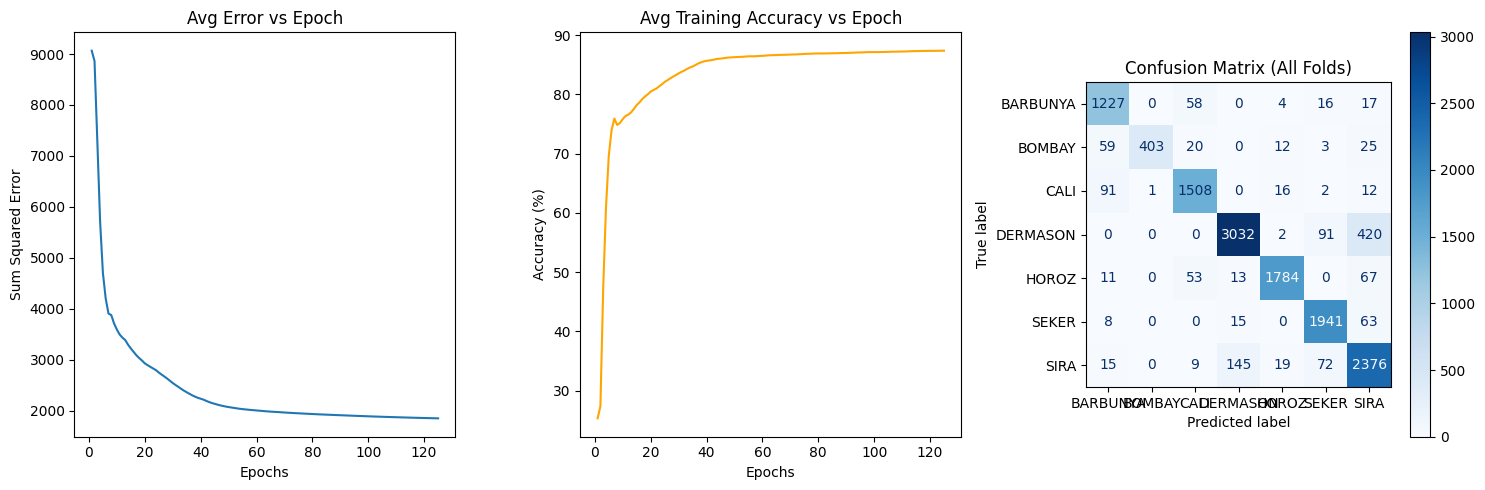

In [ ]:
# ================================
# IMPORTS
# ================================
from random import seed, random, randrange
from math import exp
from csv import reader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# ================================
# LOAD DATASET
# ================================
def load_csv(filename):
    dataset = list()
    with open(filename, 'r', encoding='utf-8-sig') as file:
        csv_reader = reader(file)

        # Skip header row
        next(csv_reader)

        for row in csv_reader:
            if not row:
                continue
            dataset.append(row)

    return dataset

def str_column_to_float(dataset, column):
    for row in dataset:
      row[column] = float(row[column].strip())

def str_column_to_int(dataset, column):
    class_values = [row[column] for row in dataset]
    unique = sorted(list(set(class_values)))
    lookup = dict()
    for i, value in enumerate(unique):
        lookup[value] = i
    for row in dataset:
        row[column] = lookup[row[column]]
    return lookup

def dataset_minmax(dataset):
    minmax = []
    n_features = len(dataset[0]) - 1

    for i in range(n_features):
        col = [row[i] for row in dataset]
        minmax.append([min(col), max(col)])

    return minmax


def normalize_with_minmax(dataset, minmax):
    n_features = len(dataset[0]) - 1

    for row in dataset:
        for i in range(n_features):
            min_val, max_val = minmax[i]

            if max_val == min_val:
                row[i] = 0.0
            else:
                row[i] = (row[i] - min_val) / (max_val - min_val)
# ================================
# K-FOLD SPLIT
# ================================
def cross_validation_split(dataset, n_folds):
    dataset_split = list()
    dataset_copy = list(dataset)
    fold_size = int(len(dataset) / n_folds)
    for _ in range(n_folds):
        fold = list()
        while len(fold) < fold_size:
            index = randrange(len(dataset_copy))
            fold.append(dataset_copy.pop(index))
        dataset_split.append(fold)
    return dataset_split

def accuracy_metric(actual, predicted):
    correct = 0
    for i in range(len(actual)):
        if actual[i] == predicted[i]:
            correct += 1
    return correct / float(len(actual)) * 100.0

# ================================
# MLP FUNCTIONS
# ================================
def initialize_network(n_inputs, h1, h2, h3, n_outputs):
    network = []

    # Hidden Layer 1
    hidden_layer_1 = [{'weights': [random() - 0.5 for _ in range(n_inputs + 1)]} for _ in range(h1)]
    network.append(hidden_layer_1)

    # Hidden Layer 2
    hidden_layer_2 = [{'weights': [random() - 0.5 for _ in range(h1 + 1)]} for _ in range(h2)]
    network.append(hidden_layer_2)

    # Hidden Layer 3
    hidden_layer_3 = [{'weights': [random() - 0.5 for _ in range(h2 + 1)]} for _ in range(h3)]
    network.append(hidden_layer_3)

    # Output Layer
    output_layer = [{'weights': [random() - 0.5 for _ in range(h3 + 1)]} for _ in range(n_outputs)]
    network.append(output_layer)

    return network

def activate(weights, inputs):
    activation = weights[-1]  # bias
    for i in range(len(weights) - 1):
        activation += weights[i] * inputs[i]
    return activation

def transfer(activation):
    return 1.0 / (1.0 + exp(-activation))  # sigmoid

def forward_propagate(network, row):
    inputs = row
    for layer in network:
        new_inputs = []
        for neuron in layer:
            activation = activate(neuron['weights'], inputs)
            neuron['output'] = transfer(activation)
            new_inputs.append(neuron['output'])
        inputs = new_inputs
    return inputs

def transfer_derivative(output):
    return output * (1.0 - output)

def backward_propagate_error(network, expected):
    for i in reversed(range(len(network))):
        layer = network[i]
        errors = list()
        if i != len(network) - 1:
            for j in range(len(layer)):
                error = 0.0
                for neuron in network[i + 1]:
                    error += neuron['weights'][j] * neuron['delta']
                errors.append(error)
        else:  # output layer
            for j in range(len(layer)):
                neuron = layer[j]
                errors.append(neuron['output'] - expected[j])
        for j in range(len(layer)):
            neuron = layer[j]
            neuron['delta'] = errors[j] * transfer_derivative(neuron['output'])

def update_weights(network, row, l_rate):
    for i in range(len(network)):
        inputs = row[:-1]
        if i != 0:
            inputs = [neuron['output'] for neuron in network[i - 1]]
        for neuron in network[i]:
            for j in range(len(inputs)):
                neuron['weights'][j] -= l_rate * neuron['delta'] * inputs[j]
            neuron['weights'][-1] -= l_rate * neuron['delta']

def train_network(network, train, l_rate, n_epoch, n_outputs):
    errors = []
    accuracies = []

    for epoch in range(n_epoch):
        sum_error = 0.0
        correct = 0
        for row in train:
            outputs = forward_propagate(network, row[:-1])
            expected = [0 for _ in range(n_outputs)]
            expected[row[-1]] = 1

            # Accuracy Check
            prediction = outputs.index(max(outputs))
            if prediction == row[-1]:
                correct += 1

            sum_error += sum(
            (expected[i] - outputs[i]) ** 2
            for i in range(len(expected)))
            backward_propagate_error(network, expected)
            update_weights(network, row, l_rate)

        print(f">epoch={epoch+1}, lrate={l_rate:.3f}, error={sum_error:.5f}")

        errors.append(sum_error)
        accuracies.append((correct / len(train)) * 100)

    return errors, accuracies

def predict(network, row):
    outputs = forward_propagate(network, row[:-1])
    return outputs.index(max(outputs))

# ================================
# MLP WITH K-FOLD
# ================================
def mlp(train, test, l_rate, n_epoch, h1, h2, h3):
    n_inputs = len(train[0]) - 1
    n_outputs = len(set(row[-1] for row in train))

    # Initialize simplified network
    network = initialize_network(n_inputs, h1, h2, h3, n_outputs)

    # Train
    errors, accuracies = train_network(network, train, l_rate, n_epoch, n_outputs)

    # Predict
    predictions = list()
    for row in test:
        prediction = predict(network, row)
        predictions.append(prediction)
    return predictions, errors, accuracies

def evaluate_algorithm(dataset, algorithm, n_folds, *args):
    folds = cross_validation_split(dataset, n_folds)
    scores = []
    all_errors = []
    all_accuracies = []

    # NEW: Lists to store GLOBAL data for Confusion Matrix
    global_actual = []
    global_predicted = []

    for fold in folds:
        train_set = list(folds)
        train_set.remove(fold)
        train_set = sum(train_set, [])
        test_set = list()
        for row in fold:
            row_copy = list(row)
            test_set.append(row_copy)
            row_copy[-1] = None
        train_minmax = dataset_minmax(train_set)

        normalize_with_minmax(train_set, train_minmax)
        normalize_with_minmax(test_set, train_minmax)
        predicted, errors, accuracies = algorithm(train_set, test_set, *args)

        all_errors.append(errors)
        all_accuracies.append(accuracies)

        actual = [row[-1] for row in fold]

        # Collect for global metrics
        global_actual.extend(actual)
        global_predicted.extend(predicted)

        accuracy = accuracy_metric(actual, predicted)
        scores.append(accuracy)

    return scores, all_errors, all_accuracies, global_actual, global_predicted

# ================================
# RUN ON DRY BEAN DATASET
# ================================
seed(1)
filename = "Dry_Bean_Dataset.csv"
dataset = load_csv(filename)

# Convert feature columns to float
for i in range(len(dataset[0]) - 1):
    str_column_to_float(dataset, i)

# Convert class column to int and CAPTURE LOOKUP for labels
class_lookup = str_column_to_int(dataset, len(dataset[0]) - 1)
# Create a list of labels sorted by index (0, 1) for the confusion matrix
labels = [k for k, v in sorted(class_lookup.items(), key=lambda item: item[1])]

# FIXED HYPERPARAMETERS
n_folds = 5
l_rate  = 0.05
n_epoch = 125
h1      = 64
h2      = 32
h3      = 16

print("Starting training...")
scores, all_errors, all_accuracies, global_act, global_pred = evaluate_algorithm(dataset, mlp, n_folds, l_rate, n_epoch, h1, h2, h3)

print("\nScores per fold:", scores)
print("Mean Accuracy: %.2f%%" % (sum(scores) / len(scores)))
precision = precision_score(
    global_act,
    global_pred,
    average='macro'
)

recall = recall_score(
    global_act,
    global_pred,
    average='macro'
)

f1 = f1_score(
    global_act,
    global_pred,
    average='macro'
)

print("Precision: %.4f" % precision)
print("Recall: %.4f" % recall)
print("F1 Score: %.4f" % f1)

# ================================
# PLOTTING
# ================================

# 1. Error vs Epoch
avg_error = [0] * n_epoch
for fold_errors in all_errors:
    for i in range(n_epoch):
        avg_error[i] += fold_errors[i]
avg_error = [e / len(all_errors) for e in avg_error]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(range(1, n_epoch+1), avg_error)
plt.xlabel("Epochs")
plt.ylabel("Sum Squared Error")
plt.title("Avg Error vs Epoch")

# 2. Training Accuracy vs Epoch
avg_acc = [0] * n_epoch
for fold_acc in all_accuracies:
    for i in range(n_epoch):
        avg_acc[i] += fold_acc[i]
avg_acc = [a / len(all_accuracies) for a in avg_acc]

plt.subplot(1, 3, 2)
plt.plot(range(1, n_epoch+1), avg_acc, color='orange')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Avg Training Accuracy vs Epoch")

# 3. Confusion Matrix (Using Sklearn Library)
cm = confusion_matrix(global_act, global_pred)
ax3 = plt.subplot(1, 3, 3)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues, ax=ax3, values_format='d')
ax3.set_title('Confusion Matrix (All Folds)')

plt.tight_layout()
plt.show()

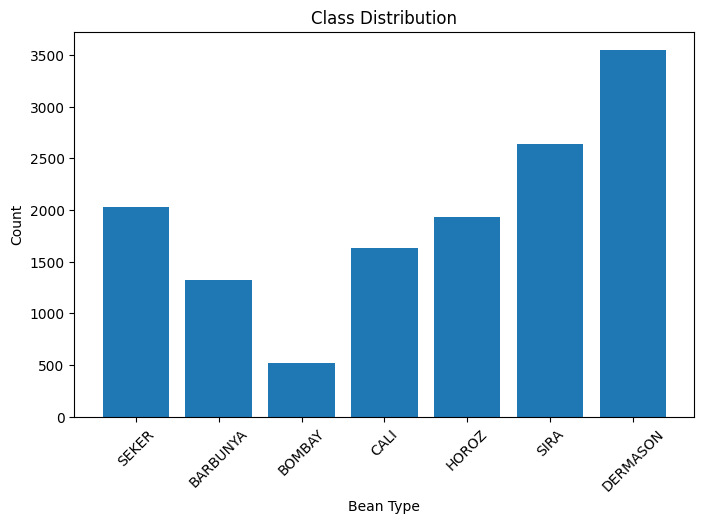

In [ ]:
from collections import Counter

class_counts = Counter(
    [row[-1] for row in dataset]
)

plt.figure(figsize=(8,5))

plt.bar(
    [labels[i] for i in class_counts.keys()],
    class_counts.values()
)

plt.xlabel("Bean Type")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.show()

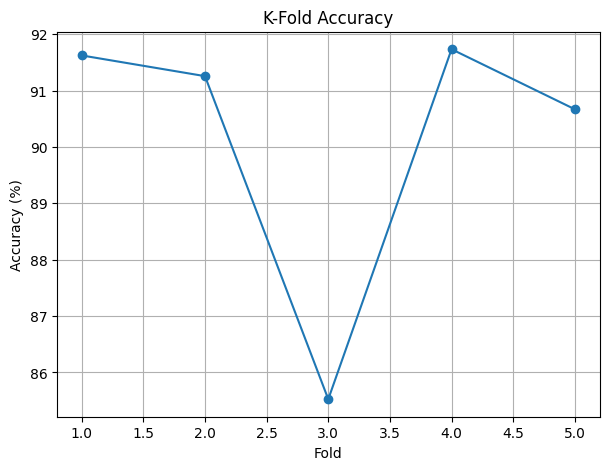

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(
    range(1, len(scores)+1),
    scores,
    marker='o'
)

plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("K-Fold Accuracy")

plt.grid(True)
plt.show()

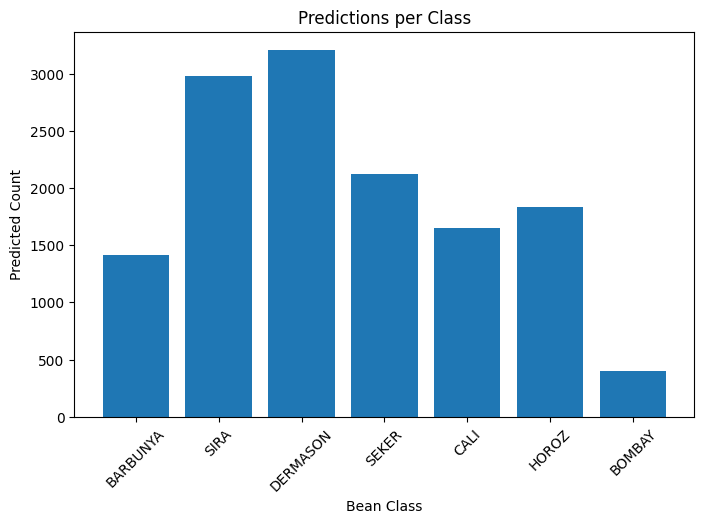

In [ ]:
from collections import Counter

pred_counts = Counter(global_pred)

plt.figure(figsize=(8,5))

plt.bar(
    [labels[i] for i in pred_counts.keys()],
    pred_counts.values()
)

plt.xlabel("Bean Class")
plt.ylabel("Predicted Count")
plt.title("Predictions per Class")

plt.xticks(rotation=45)

plt.show()

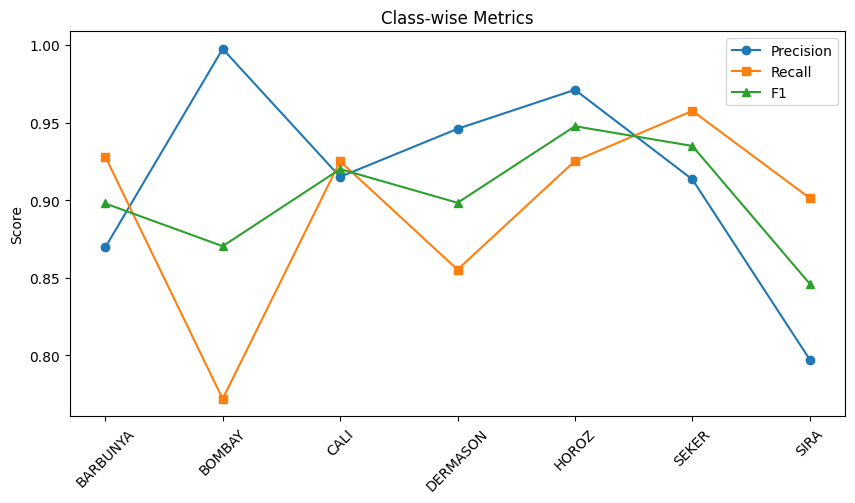

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, _ = precision_recall_fscore_support(
    global_act,
    global_pred
)

x = range(len(labels))

plt.figure(figsize=(10,5))

plt.plot(x, prec, marker='o', label='Precision')
plt.plot(x, rec, marker='s', label='Recall')
plt.plot(x, f1, marker='^', label='F1')

plt.xticks(x, labels, rotation=45)

plt.ylabel("Score")
plt.title("Class-wise Metrics")
plt.legend()

plt.show()